In [14]:
#Step1 : Import required Libraries

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plot

import os


In [15]:
#Step 2 : Define Dataset Paths

Train_Dir="./Tomato_Split/train"
Validation_Dir="./Tomato_Split/validation"
Test_Dir="./Tomato_Split/test"


In [16]:
#Step 3: Set Image Prameters

IMG_HEIGHT=224
IMG_WIDTH=224
BATCH_SIZE=32
EPOCHS=10

In [17]:
#Step 4 : Image Preporcessing and Augmentation
train_datagen=ImageDataGenerator(
    
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
    
)

validation_datagen=ImageDataGenerator(
    rescale=1./255
)



In [18]:
# Step 5 : Load Images from folder

train_data=train_datagen.flow_from_directory(
    
    Train_Dir,
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


validation_data=validation_datagen.flow_from_directory(
    
    Validation_Dir,
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data=validation_datagen.flow_from_directory(
    
    Test_Dir,
    target_size=(IMG_HEIGHT,IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES=train_data.num_classes
print("Number of classes : ",NUM_CLASSES)
print("Class Labels : ",train_data.class_indices)

Found 3100 images belonging to 10 classes.
Found 660 images belonging to 10 classes.
Found 680 images belonging to 10 classes.
Number of classes :  10
Class Labels :  {'bacterial_spot': 0, 'early_blight': 1, 'healthy': 2, 'late_blight': 3, 'leaf_mold': 4, 'mosaic_virus': 5, 'septoria_leaf_spot': 6, 'target_spot': 7, 'twospotted_spider_mite': 8, 'yellow_leaf_curl_virus': 9}


In [19]:
# Step 6 : Build CNN Model

model=Sequential()

model.add( Conv2D( 32,(3,3),activation='relu',input_shape=(IMG_HEIGHT,IMG_WIDTH,3)) )

model.add(MaxPooling2D(2,2))

model.add( Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))


model.add( Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu') )

model.add(Dropout(0.5))

model.add( Dense(NUM_CLASSES,activation='softmax') )

C:\Users\User\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Step7 Compile the model

model.compile(
    
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
# Step 8 Train the model

history=model.fit(
    
    train_data,
    validation_data=validation_data,
    epochs=EPOCHS
    
)

Epoch 1/10


C:\Users\User\AppData\Roaming\Python\Python39\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


97/97 ━━━━━━━━━━━━━━━━━━━━ 406s 4s/step - accuracy: 0.1358 - loss: 2.5398 - val_accuracy: 0.3318 - val_loss: 1.8336
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 398s 4s/step - accuracy: 0.3385 - loss: 1.8336 - val_accuracy: 0.4833 - val_loss: 1.4336
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 395s 4s/step - accuracy: 0.4541 - loss: 1.5114 - val_accuracy: 0.6045 - val_loss: 1.1004
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 388s 4s/step - accuracy: 0.5200 - loss: 1.3349 - val_accuracy: 0.6515 - val_loss: 0.9961
Epoch 5/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 404s 4s/step - accuracy: 0.6053 - loss: 1.1485 - val_accuracy: 0.6000 - val_loss: 1.1911
Epoch 6/10


KeyboardInterrupt: 

In [ ]:
# Step 10 : Save the model

model.save("tomato_plant_disease_cnn.h5")
print("Model saved")

Model saved


In [ ]:
import json

# Get class indices
class_indices = train_data.class_indices

# Reverse the dictionary (index -> class name)
class_names = {v: k for k, v in class_indices.items()}

print(class_names)

# Save as JSON
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved successfully.")

{0: 'bacterial_spot', 1: 'early_blight', 2: 'healthy', 3: 'late_blight', 4: 'leaf_mold', 5: 'mosaic_virus', 6: 'septoria_leaf_spot', 7: 'target_spot', 8: 'twospotted_spider_mite', 9: 'yellow_leaf_curl_virus'}
Class names saved successfully.


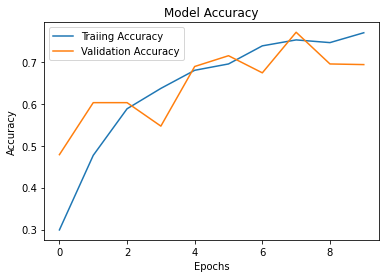

In [ ]:
# Step 12 Plot accuracy and loss

plot.figure()

plot.plot(history.history['accuracy'],label='Traiing Accuracy')

plot.plot(history.history['val_accuracy'],
          label='Validation Accuracy')
plot.title('Model Accuracy')
plot.xlabel('Epochs')
plot.ylabel('Accuracy')
plot.legend()
plot.show()



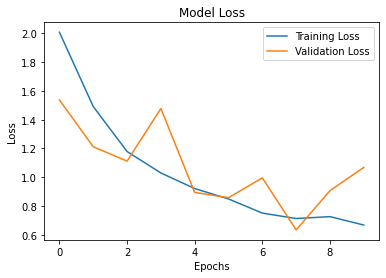

In [ ]:
plot.figure()
plot.plot( history.history['loss'],label='Training Loss')
plot.plot( history.history['val_loss'],label='Validation Loss')

plot.title("Model Loss")
plot.xlabel('Epochs')
plot.ylabel('Loss')
plot.legend()
plot.show()


In [24]:
from tensorflow.keras.models import load_model

In [25]:
model=load_model("tomato_plant_disease_cnn.h5")

In [26]:
pred=model.predict(test_data)

C:\Users\User\AppData\Roaming\Python\Python39\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 628ms/step


In [29]:
pred

array([[8.7163323e-01, 5.1954117e-02, 1.8807543e-05, ..., 3.9313834e-02,
        2.9265536e-03, 4.3979585e-03],
       [4.7858456e-01, 1.4925212e-01, 8.7627932e-06, ..., 1.4897168e-03,
        3.8987258e-03, 2.3647476e-02],
       [9.9245399e-01, 6.4634206e-03, 1.7222892e-07, ..., 6.4461119e-04,
        2.0670959e-05, 2.8908715e-04],
       ...,
       [4.2520668e-03, 5.6136789e-04, 4.3103881e-07, ..., 1.4309488e-04,
        5.3968589e-04, 9.9315709e-01],
       [1.6233893e-04, 7.4485961e-06, 5.0265709e-07, ..., 6.3303584e-04,
        3.0420238e-01, 6.9493675e-01],
       [1.1406951e-08, 2.7707683e-08, 1.0945951e-12, ..., 2.7692572e-08,
        1.7585557e-05, 9.9998224e-01]], dtype=float32)

In [40]:
pred.shape

(680, 10)

In [30]:
import numpy as np
pred_classes=np.argmax(pred,axis=1)

In [41]:
pred_classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 1, 0, 6, 0, 0, 0, 1, 0,
       9, 6, 2, 1, 3, 1, 4, 7, 1, 6, 1, 6, 7, 1, 1, 9, 1, 1, 1, 8, 1, 1,
       1, 3, 1, 1, 1, 6, 1, 6, 1, 1, 1, 1, 1, 1, 6, 1, 3, 1, 1, 4, 1, 1,
       5, 7, 1, 1, 1, 7, 1, 6, 1, 1, 1, 4, 1, 9, 5, 1, 1, 1, 7, 3, 6, 1,
       6, 1, 5, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 3, 2, 1, 2, 1, 2, 1, 1, 2, 2, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 3, 3, 6, 3, 6, 7, 3, 1, 6, 6, 3, 5, 3, 3, 3, 3,
       3, 3, 2, 6, 3, 3, 3, 2, 3, 3, 6, 4, 3, 2, 3, 3, 3, 3, 3, 4, 3, 3,
       3, 3, 3, 3, 2, 4, 3, 3, 6, 3, 8, 3, 6, 3, 3, 3, 3, 3, 3, 3, 6, 6,
       3, 3, 6, 6, 3, 3, 3, 3, 5, 4, 4, 5, 1, 4, 4, 6, 4, 4, 4, 4, 4, 5,
       6, 6, 4, 4, 4, 5, 4, 2, 4, 4, 4, 4, 4, 4, 6,

In [42]:
pred_classes.shape

(680,)

In [34]:
true_classes=test_data.classes

In [35]:
true_classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,

In [36]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [ ]:
cm=confusion_matrix(true_classes,pred_classes,)
print(cm)

[[58  2  0  0  0  0  3  2  0  3]
 [ 0 40  1  4  4  3  8  5  1  2]
 [ 0  8 58  1  1  0  0  0  0  0]
 [ 0  1  4 45  3  1 12  1  1  0]
 [ 0  2  1  0 42  9 14  0  0  0]
 [ 0  0  2  0  1 61  3  0  1  0]
 [ 0  1  1  1  1  2 55  5  0  2]
 [ 0  0 37  0  0  0  4 24  3  0]
 [ 0  0 18  0  0  1  4  4 41  0]
 [ 1  1  0  1  0  2  2  0  1 60]]


In [43]:
cr=classification_report(true_classes,pred_classes)

In [44]:
print(cr)

              precision    recall  f1-score   support

           0       0.98      0.85      0.91        68
           1       0.73      0.59      0.65        68
           2       0.48      0.85      0.61        68
           3       0.87      0.66      0.75        68
           4       0.81      0.62      0.70        68
           5       0.77      0.90      0.83        68
           6       0.52      0.81      0.64        68
           7       0.59      0.35      0.44        68
           8       0.85      0.60      0.71        68
           9       0.90      0.88      0.89        68

    accuracy                           0.71       680
   macro avg       0.75      0.71      0.71       680
weighted avg       0.75      0.71      0.71       680

